# Plots generated by experiments

In [122]:
import pickle
import numpy as np


In [123]:
experiment_dir = './experiments/'
N_values = [10, 25, 50, 100, 200, 499]


In [124]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np
import pickle

# -- Style ------------------------------------------------------------------
C_TRANSFORMER = '#002d4d'
C_LAPLACE     = '#177F6B'
C_ENTROPY     = '#888888'
BG            = '#FFFFFF'
GRID          = '#E0E0E0'

matplotlib.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.facecolor':    BG,
    'figure.facecolor':  BG,
    'axes.edgecolor':    GRID,
    'axes.linewidth':    0.8,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.labelsize':    10,
    'axes.titlesize':    10,
    'axes.titleweight':  'bold',
    'legend.fontsize':   9,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  GRID,
    'lines.linewidth':   1.0,
    'lines.markersize':  4.5,
})

def style_ax(ax):
    ax.grid(True, axis='y', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def set_log_xticks(ax, vals):
    ax.set_xscale('log')
    ax.set_xticks(vals)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='x', rotation=40)

def load_experiment(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

experiment_dir = './experiments/'
N_values = [10, 25, 50, 100, 200, 300, 499]


def plot_bps_per_p(all_results, p_values, N_values, n_trials=100, save_stem='iid_bps_per_p'):
    import os; os.makedirs('figures', exist_ok=True)
    n = len(p_values)

    # single panel: no GridSpec needed
    if n == 1:
        fig, ax = plt.subplots(figsize=(5.5, 4), dpi=150)
        fig.patch.set_facecolor(BG)
        all_axes = [ax]
        _fill_bps_ax(ax, all_results, p_values[0], N_values, n_trials)
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=4,
                   bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=9)
        ax.get_legend().remove()
        plt.tight_layout(rect=[0, 0.1, 1, 1])
    else:
        # 3-top + remainder-bottom GridSpec layout
        n_top = min(3, n)
        n_bot = n - n_top
        fig = plt.figure(figsize=(11, 8))
        fig.patch.set_facecolor(BG)
        if n_bot > 0:
            gs_top = gridspec.GridSpec(1, n_top, top=0.89, bottom=0.53,
                                       left=0.07, right=0.97, wspace=0.38)
            pad_l  = (1 - n_bot * (0.90 / n_top)) / 2 + 0.07
            pad_r  = 1 - pad_l
            gs_bot = gridspec.GridSpec(1, n_bot, top=0.44, bottom=0.12,
                                       left=pad_l, right=pad_r, wspace=0.38)
            axes_top = [fig.add_subplot(gs_top[0, i]) for i in range(n_top)]
            axes_bot = [fig.add_subplot(gs_bot[0, i]) for i in range(n_bot)]
            all_axes = axes_top + axes_bot
        else:
            gs = gridspec.GridSpec(1, n_top, top=0.89, bottom=0.15,
                                   left=0.07, right=0.97, wspace=0.38)
            all_axes = [fig.add_subplot(gs[0, i]) for i in range(n_top)]

        for ax, p_true in zip(all_axes, p_values):
            _fill_bps_ax(ax, all_results, p_true, N_values, n_trials)

        handles, labels = all_axes[0].get_legend_handles_labels()
        for ax in all_axes:
            ax.get_legend().remove()
        fig.legend(handles, labels, loc='lower center', ncol=4,
                   bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=10)
        fig.suptitle('Experiment 1 - Transformer vs Laplace: BPS vs Sequence Length',
                     fontsize=12, fontweight='bold', y=0.97)

    plt.savefig(f'figures/{save_stem}.pdf', bbox_inches='tight', dpi=150)
    plt.savefig(f'figures/{save_stem}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved figures/{save_stem}')


def _fill_bps_ax(ax, all_results, p_true, N_values, n_trials):
    means_lap = [all_results[p_true][N]['laplace'][0]     for N in N_values]
    stds_lap  = [all_results[p_true][N]['laplace'][1]     for N in N_values]
    means_tr  = [all_results[p_true][N]['transformer'][0] for N in N_values]
    stds_tr   = [all_results[p_true][N]['transformer'][1] for N in N_values]
    entropy   = all_results[p_true][N_values[0]]['entropy']
    se_lap    = [s / n_trials**0.5 for s in stds_lap]
    se_tr     = [s / n_trials**0.5 for s in stds_tr]

    ax.errorbar(N_values, means_lap, yerr=se_lap, fmt='o-', capsize=3,
                color=C_LAPLACE, lw=1.0, ms=4.5, label='Laplace')
    ax.errorbar(N_values, means_tr,  yerr=se_tr,  fmt='s-', capsize=3,
                color=C_TRANSFORMER, lw=1.0, ms=4.5, label='Transformer')
    ax.axhline(y=entropy, color=C_ENTROPY, linestyle=':', lw=1.0,
               label=f'$H(p)={entropy:.3f}$')
    set_log_xticks(ax, N_values)
    ax.set_title(f'$p = {p_true}$', fontsize=9.5, pad=5)
    ax.set_xlabel('Sequence length ($N$)', fontsize=9)
    ax.set_ylabel('Bits per symbol', fontsize=9)
    ax.legend(loc='upper right', fontsize=8)
    style_ax(ax)


def plot_gap(all_results, p_values, N_values, save_stem='iid_gap'):
    import os, matplotlib.cm as cm
    os.makedirs('figures', exist_ok=True)
    cmap = cm.get_cmap('viridis', len(p_values))
    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    fig.patch.set_facecolor(BG)

    for i, p_true in enumerate(p_values):
        gaps = [all_results[p_true][N]['laplace'][0] - all_results[p_true][N]['transformer'][0]
                for N in N_values]
        ax.plot(N_values, gaps, marker='o', lw=1.0, ms=4.5,
                color=cmap(i), label=f'$p={p_true}$')

    ax.axhline(y=0, color='black', linestyle='--', lw=1.0)
    set_log_xticks(ax, N_values)
    ax.set_xlabel('Sequence length ($N$)', fontsize=9)
    ax.set_ylabel('Laplace BPS $-$ Transformer BPS', fontsize=9)
    ax.legend()
    style_ax(ax)
    plt.tight_layout()
    plt.savefig(f'figures/{save_stem}.pdf', bbox_inches='tight', dpi=150)
    plt.savefig(f'figures/{save_stem}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved figures/{save_stem}')


In [125]:
def load_experiment(file):
    with open(experiment_dir + file, 'rb') as f:
        return pickle.load(f)

{0.1: {10: {'laplace': (np.float64(0.6279287661580266), np.float64(0.22728045034260363)), 'transformer': (np.float64(0.6288571723208732), np.float64(0.23407648565601336)), 'entropy': np.float64(0.4689955935892812)}, 25: {'laplace': (np.float64(0.5565379781126026), np.float64(0.1680704674938223)), 'transformer': (np.float64(0.560645736671834), np.float64(0.16903445117840346)), 'entropy': np.float64(0.4689955935892812)}, 50: {'laplace': (np.float64(0.49464052198783454), np.float64(0.12928716637047283)), 'transformer': (np.float64(0.49754571615496046), np.float64(0.13051777963471436)), 'entropy': np.float64(0.4689955935892812)}, 100: {'laplace': (np.float64(0.49437330206071733), np.float64(0.08299754405686403)), 'transformer': (np.float64(0.4963847131957431), np.float64(0.08324277850596225)), 'entropy': np.float64(0.4689955935892812)}, 200: {'laplace': (np.float64(0.48822222219975636), np.float64(0.06051114128310574)), 'transformer': (np.float64(0.48911096342688326), np.float64(0.06043407

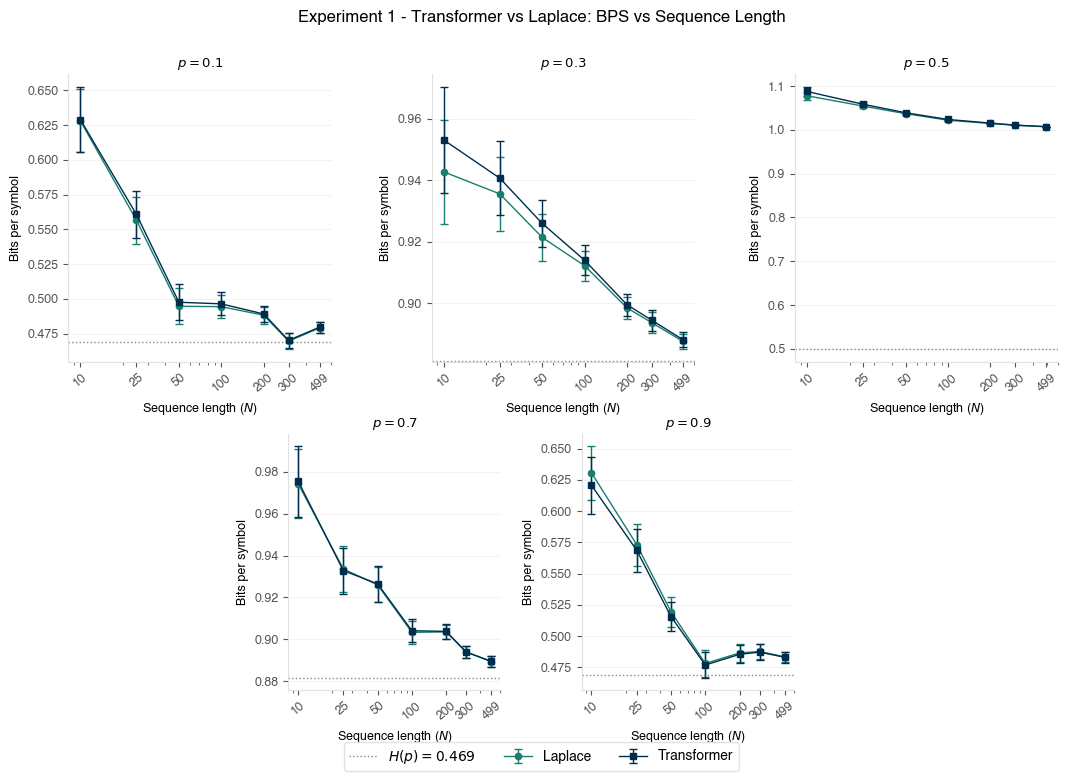

Saved figures/iid_bps_per_p


/var/folders/pz/w_rt31m10t975klq24h8_qj00000gn/T/ipykernel_63993/2153060744.py:136: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(p_values))


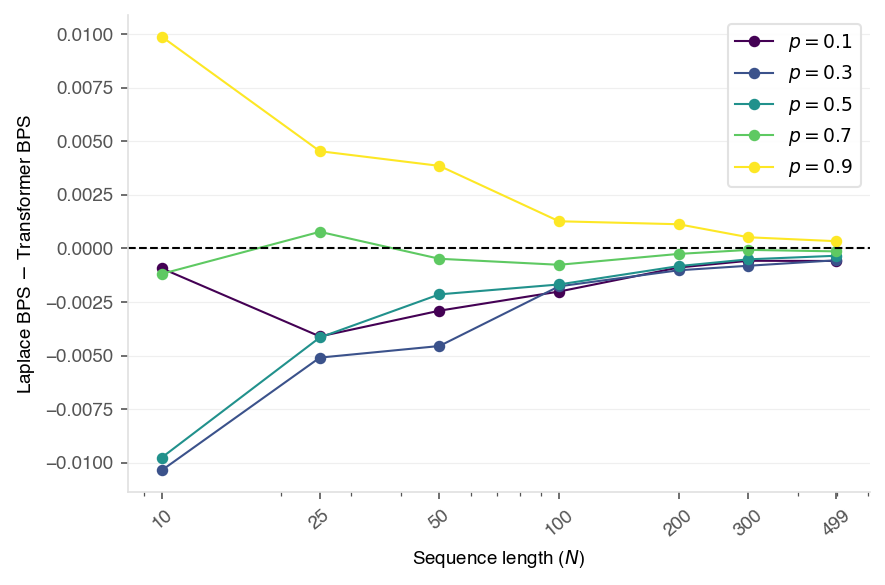

Saved figures/iid_gap


In [126]:
iid_results = load_experiment('iid_experiment.pkl')
print(iid_results)
N_values = sorted(next(iter(iid_results.values())).keys())
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
plot_bps_per_p(iid_results, p_values, N_values)
plot_gap(iid_results, p_values, N_values)

{0.3: {10: {'laplace': (np.float64(0.9760889276494916), np.float64(0.18643968114482196)), 'transformer': (np.float64(0.9103060863749808), np.float64(0.16938317410553866)), 'entropy': np.float64(0.8812908992306927)}, 25: {'laplace': (np.float64(0.9333028409727541), np.float64(0.11050640314097432)), 'transformer': (np.float64(0.8806427964983132), np.float64(0.10773857893053367)), 'entropy': np.float64(0.8812908992306927)}, 50: {'laplace': (np.float64(0.9223438833841671), np.float64(0.08108925984655595)), 'transformer': (np.float64(0.8858968460230743), np.float64(0.07704477010768859)), 'entropy': np.float64(0.8812908992306927)}, 100: {'laplace': (np.float64(0.9139137636395114), np.float64(0.05459732660998549)), 'transformer': (np.float64(0.8901785836007694), np.float64(0.05491219073018568)), 'entropy': np.float64(0.8812908992306927)}, 200: {'laplace': (np.float64(0.900446272965285), np.float64(0.036998335731942646)), 'transformer': (np.float64(0.8860278205445279), np.float64(0.03783126761

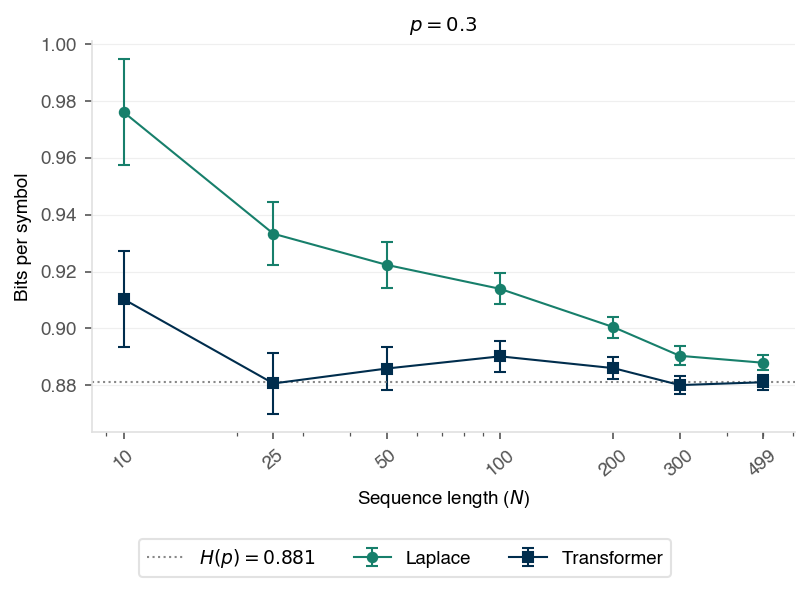

Saved figures/iid_p03


/var/folders/pz/w_rt31m10t975klq24h8_qj00000gn/T/ipykernel_63993/2153060744.py:136: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(p_values))


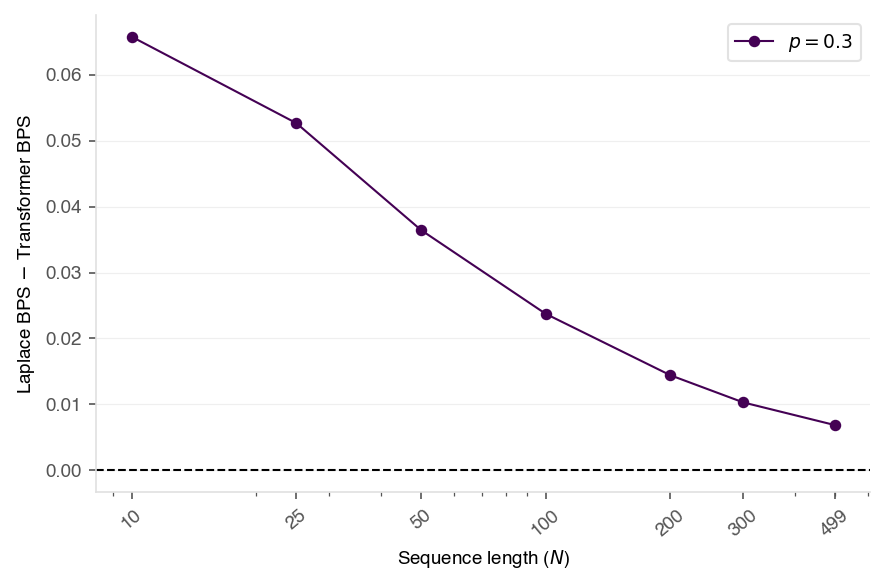

Saved figures/iid_gap


In [127]:
p03_results = load_experiment('p03_experiment.pkl')
print(p03_results)
p_values = [0.3]
N_values = sorted(next(iter(p03_results.values())).keys())
plot_bps_per_p(p03_results, p_values, N_values, save_stem='iid_p03')
plot_gap(p03_results, p_values, N_values)

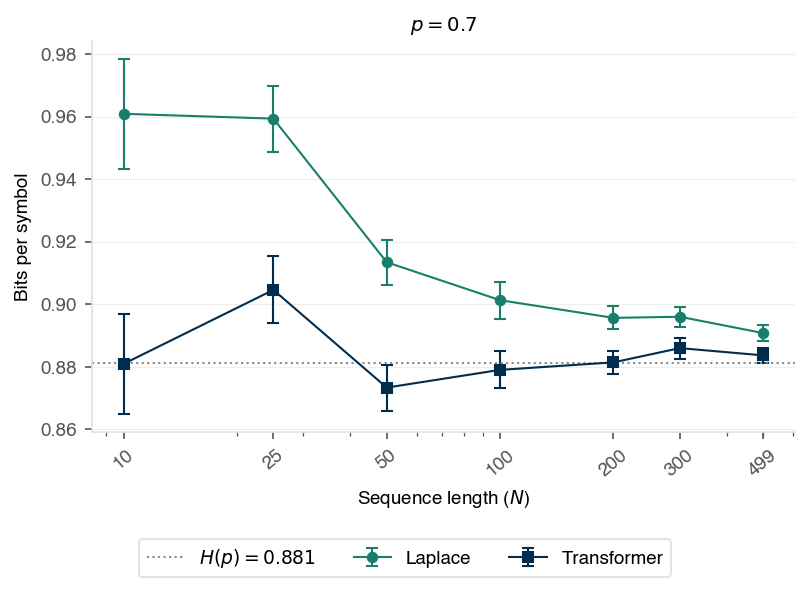

Saved figures/iid_bps_per_p


/var/folders/pz/w_rt31m10t975klq24h8_qj00000gn/T/ipykernel_63993/2153060744.py:136: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(p_values))


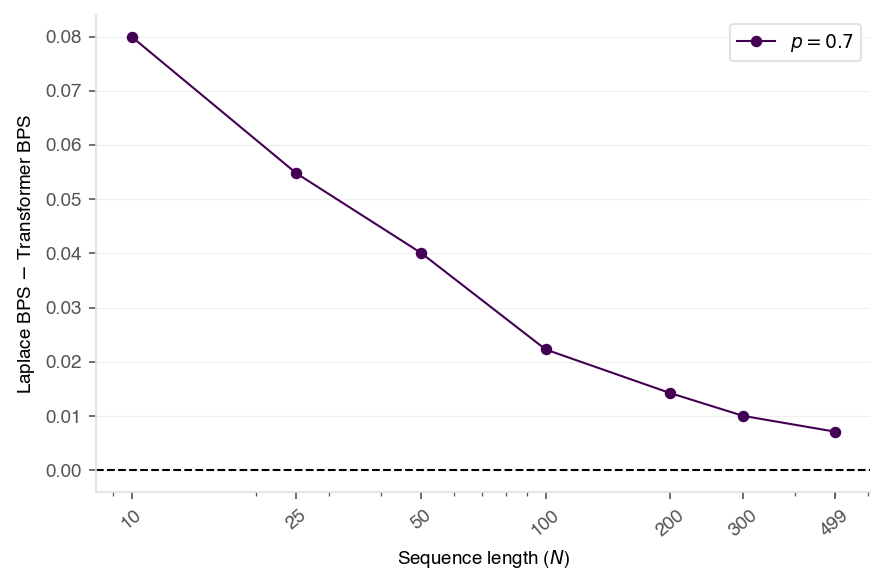

Saved figures/iid_p07


In [128]:
p07_results = load_experiment('p07_experiment.pkl')
p_values = [0.7]
N_values = sorted(next(iter(p07_results.values())).keys())
plot_bps_per_p(p07_results, p_values, N_values)
plot_gap(p07_results, p_values, N_values, save_stem='iid_p07')

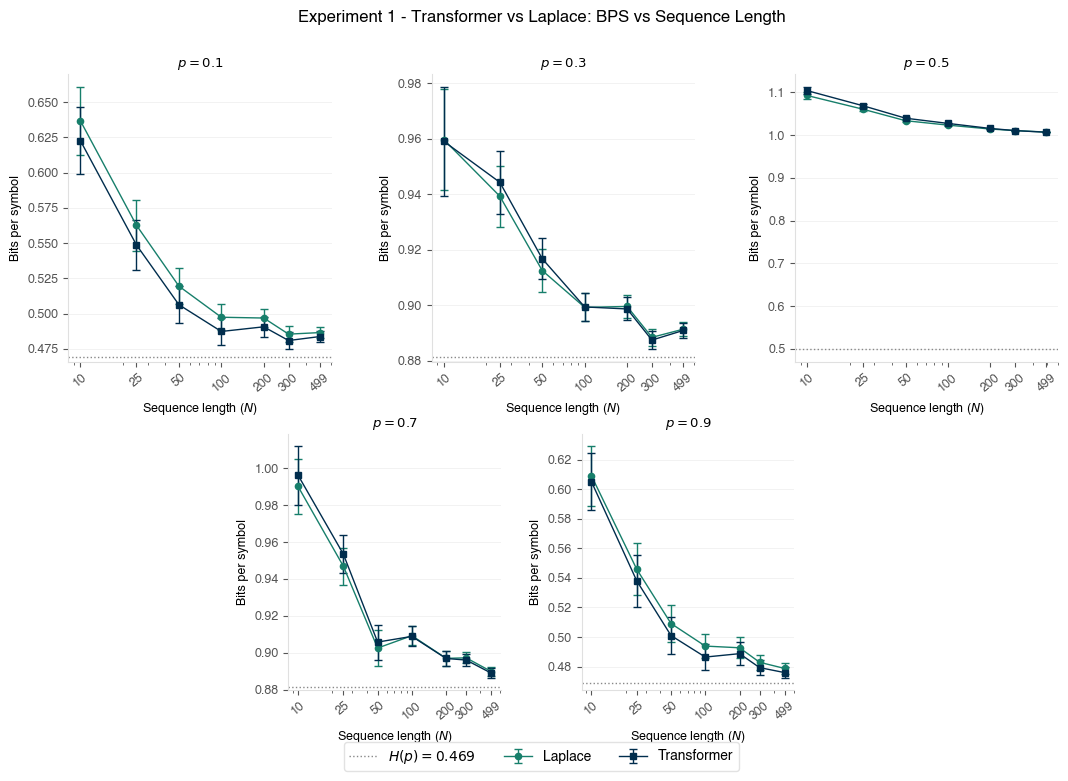

Saved figures/iid_bps_per_p


/var/folders/pz/w_rt31m10t975klq24h8_qj00000gn/T/ipykernel_63993/2153060744.py:136: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(p_values))


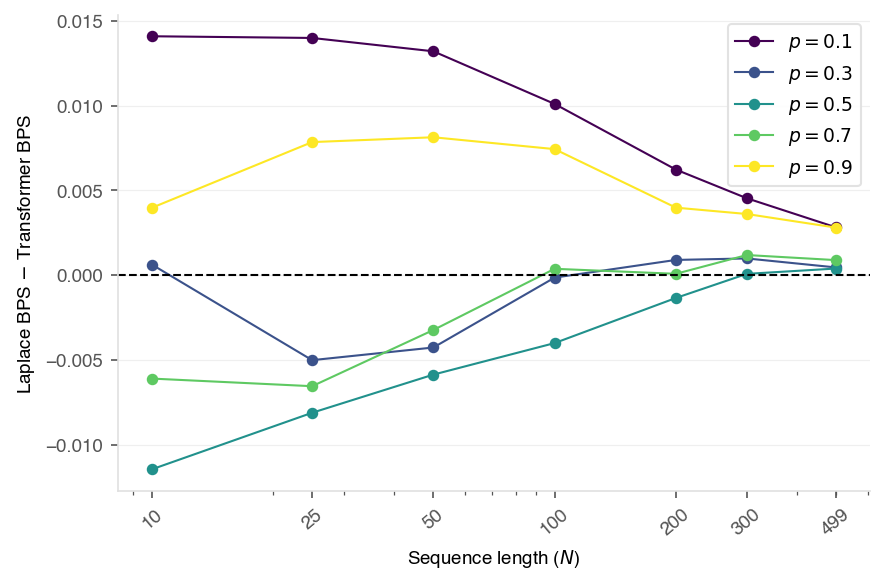

Saved figures/iid_gap


In [129]:
points_results = load_experiment('points_experiment.pkl')
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
plot_bps_per_p(points_results, p_values, N_values)
plot_gap(points_results, p_values, N_values)